In [1]:
import seaborn as sns
import pandas as pd
import plotly.express as px

In [3]:
df = sns.load_dataset("iris")

In [7]:
df_ = df.copy()
df_["species_numerical"] = df_["species"].map(
    {"setosa":0,"versicolor":1,"virginica":2})

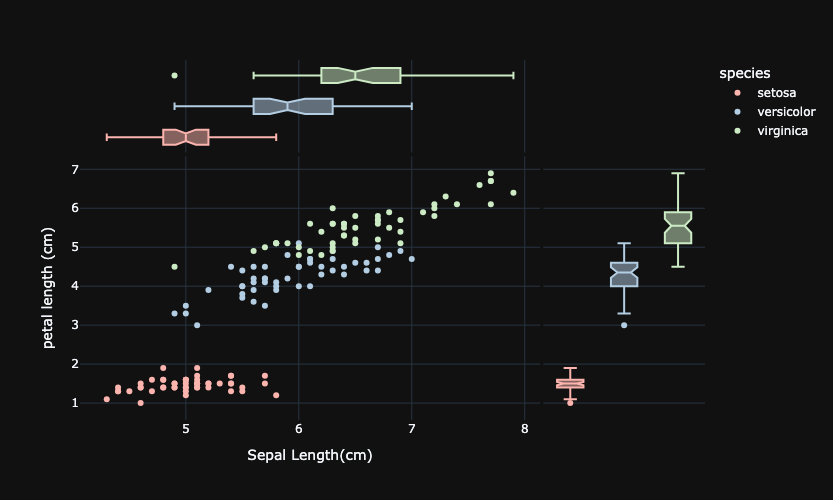

In [21]:
fig = px.scatter(df, x = 'sepal_length',y = 'petal_length', #导入数据,并指定两个轴的数据(关键字参数)
                 color = 'species',#根据关键字列指定不同的颜色,这里这列表示种类,按照种类绘制
                 marginal_x = 'box', marginal_y = 'box',#在边缘添加箱型图
                 template = "plotly_dark", #配置背景显示风格
                 width = 600,height = 500, #尺寸单位为像素
                 color_discrete_sequence = px.colors.qualitative.Pastel1, #颜色映射调色板
                 labels = {"sepal_length":"Sepal Length(cm)",
                           "petal_length":"petal length (cm)"})
fig.show()

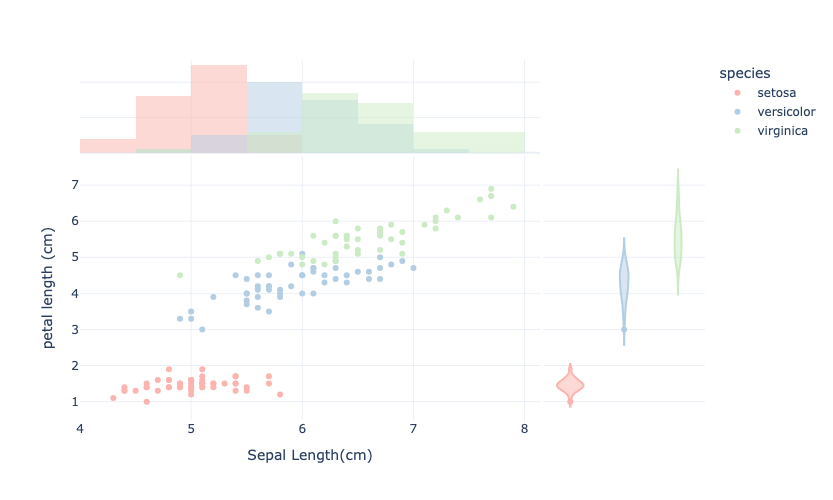

In [17]:
fig = px.scatter(df, x = 'sepal_length',y = 'petal_length', #导入数据,并指定两个轴的数据(关键字参数)
                 color = 'species',#根据关键字列指定不同的颜色,这里这列表示种类,按照种类绘制
                 marginal_x = 'histogram', marginal_y = 'violin',#在边缘添加箱型图
                 template = "plotly_white", #
                 width = 600,height = 500,
                 color_discrete_sequence = px.colors.qualitative.Pastel1,
                 labels = {"sepal_length":"Sepal Length(cm)",
                           "petal_length":"petal length (cm)"})
fig.show()

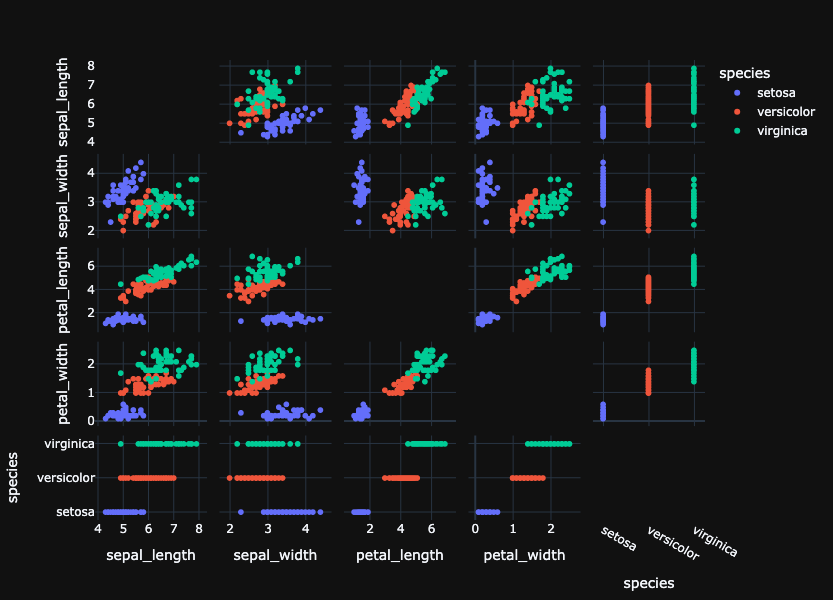

In [25]:
fig = px.scatter_matrix(df,
                        dimensions=["sepal_length","sepal_width",
                                    "petal_length","petal_width",
                                    "species"],
                        template = "plotly_dark",
                        color = 'species',width=600,height=600)
#对角线配置为不可见
fig.update_traces(diagonal_visible=False)
fig.show()

In [27]:
df['area'] = df['sepal_length'] * df['sepal_width']  #结果保存在数据帧新的列
#按照面结进行分类,将分类结果A-E分配到新的列
df['Category'] = pd.qcut(df['area'], 5,labels = ['A','B','C','D','E'])

In [39]:
import numpy as np
list_stats = ['min','max','mean','median','std'] #定义一个列表,包含这些名称
#先根据category分组,然后根据分组后的标签area计算,agg计算上个list_stats中列出的统计量
stats_by_area = df.groupby('Category')['area'].agg(list_stats)

stats_by_area['Range'] = stats_by_area['max'] - stats_by_area['min']
#方法df.value_counts默认返回降序 ,当赋值时候,会按照原列表的索引对其
stats_by_area['Number'] = df['Category'].value_counts()

/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_88868/1563371963.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [41]:
stats_by_area

,min,max,mean,median,std,Range,Number
Category,,,,,,,
A,10.00,15.00,13.421667,13.695,1.278288,5.00,30
B,15.04,16.80,15.912000,15.910,0.540532,1.76,30
C,16.83,18.30,17.623226,17.680,0.436023,1.47,31
D,18.36,20.77,19.701379,19.610,0.728044,2.41,29
E,20.79,30.02,22.525333,21.630,2.274115,9.23,30


In [37]:
stats_by_area.to_csv('stats_by_area.csv')

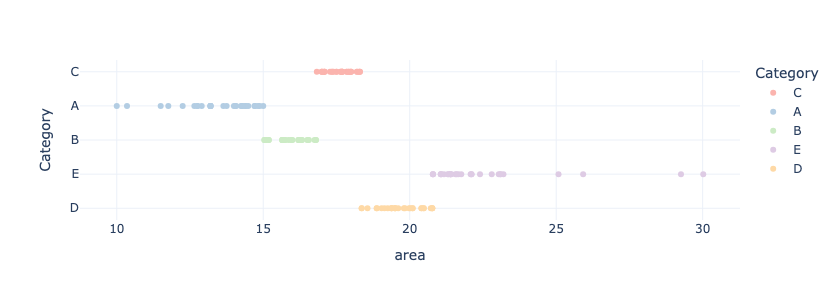

In [46]:
fig = px.scatter(df,x='area',y='Category',
                 color = 'Category',
                 template = 'plotly_white',
                 width=600,height=300,
                 color_discrete_sequence=px.colors.qualitative.Pastel1)
fig.show()

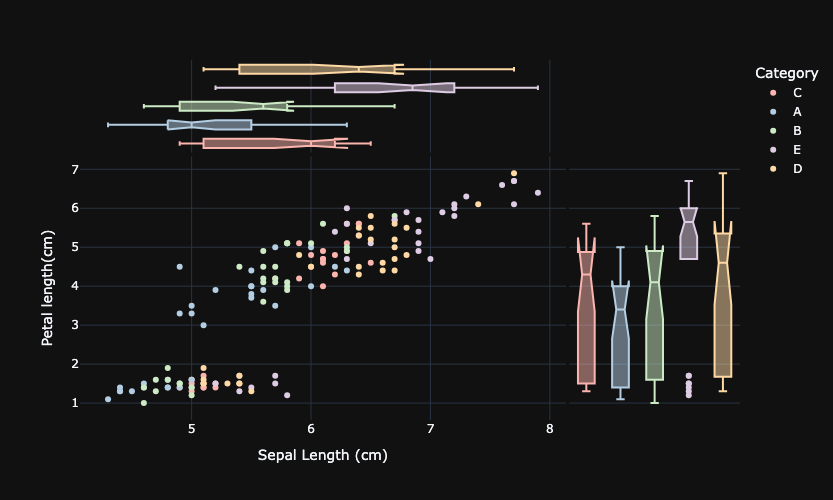

In [56]:
fig = px.scatter(df,x='sepal_length',y='petal_length',
                 color = 'Category',marginal_x='box',
                 marginal_y = 'box',template = 'plotly_dark',
                 width=600,height=500,
                 color_discrete_sequence=px.colors.qualitative.Pastel1,
                 labels={'sepal_length':'Sepal Length (cm)',
                         'petal_length':'Petal length(cm)'})
fig.show()

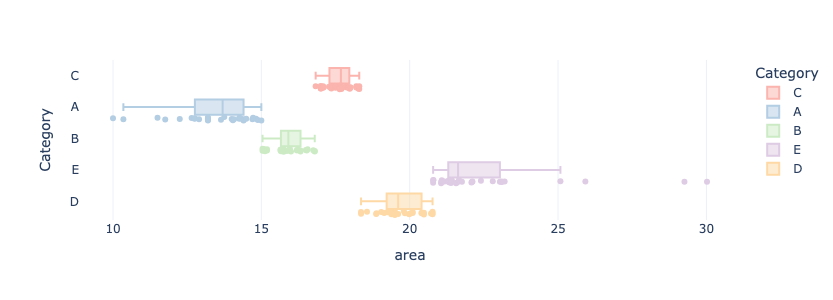

In [58]:
fig = px.box(df,x='area',y='Category',
             color = 'Category',points='all',
             template = 'plotly_white',
             width=600,height=300,
             color_discrete_sequence = px.colors.qualitative.Pastel1)
fig.show()

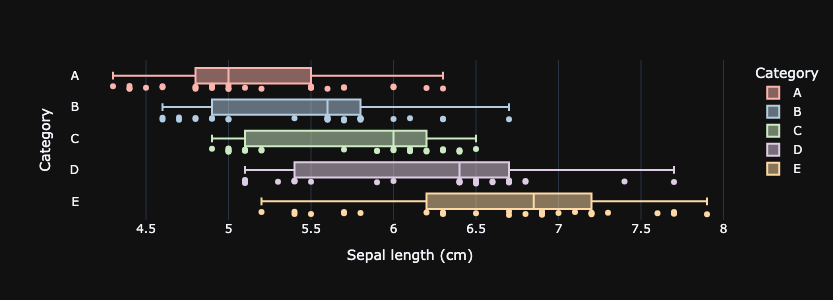

In [62]:
fig = px.box(df,x = 'sepal_length',y = 'Category',
             color = 'Category',points='all',
             template = 'plotly_dark',
             width=600,height=300,
             #orders表示顺序,plotly自动查找数值是否在此变量汇总被排序
             category_orders={'Category':['A','B','C','D','E']},
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             labels={'sepal_length':'Sepal length (cm)'})
fig.show()

In [64]:
freq_matrix = pd.crosstab(index = df['Category'],
                          columns = df['species'])

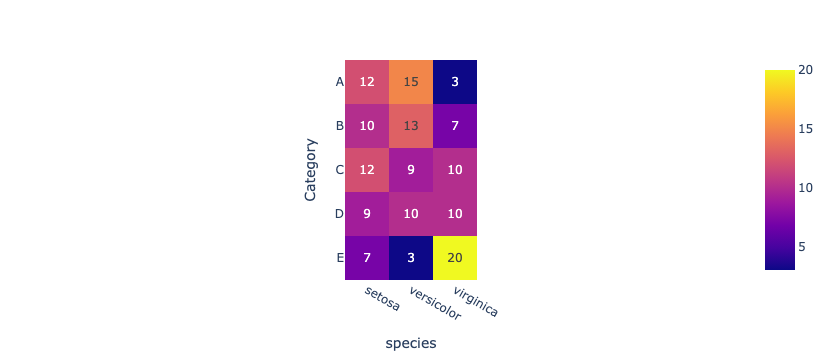

In [78]:
fig = px.imshow(freq_matrix,text_auto=True)
fig.show()

In [84]:
freq_matrix.sum(axis=1)

Category
A    30
B    30
C    31
D    29
E    30
dtype: int64

In [74]:
prob_matrix = pd.crosstab(index = df['Category'],
                           columns = df['species'],
                           normalize = 'all')#限制为二维频数

In [76]:
prob_matrix

species,setosa,versicolor,virginica
Category,,,
A,0.080000,0.100000,0.020000
B,0.066667,0.086667,0.046667
C,0.080000,0.060000,0.066667
D,0.060000,0.066667,0.066667
E,0.046667,0.020000,0.133333


In [86]:
df['Category'].value_counts().sort_index()

Category
A    30
B    30
C    31
D    29
E    30
Name: count, dtype: int64